## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

In [1]:
%pip install numpy matplotlib astropy astroplan imageio timezonefinder tzdata
%pip install "astropy-iers-data>=0.2026.3.20.0"
%pip install healpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [3]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time 

In [4]:
# Q1
now = Time.now()  # exactly one call to Time.now()
print("UTC:", now.utc.isot)
print("IIT Kanpur:", format_iitk(now))
print("Two separate Time.now() calls can differ because time continues to advance between the calls.")


UTC: 2026-09-02T18:37:36.440
IIT Kanpur: 2026-09-03 00:07:36 IST
Two separate Time.now() calls can differ because time continues to advance between the calls.


### Explanation — Q1
`Time.now()` is called exactly once and stored in `now`. The same instant is then displayed in UTC and in the IIT Kanpur civil timezone (`Asia/Kolkata`). Two separate calls can differ because the clock advances between the calls.


## Q2. Physical quantities and unit conversions 

C

In [5]:
# Q2
gtc_height = 2396 * u.m
wavelength = 600 * u.nm
coord_uncertainty = 5 * u.mas
cadence = 10 * u.min
radio_frequency = 1.4 * u.GHz

print(f"GTC height: {gtc_height} = {gtc_height.to(u.km)}")
print(f"Wavelength: {wavelength} = "
      f"{wavelength.to(u.THz, equivalencies=u.spectral())}")
print(f"Coordinate uncertainty: {coord_uncertainty} = "
      f"{coord_uncertainty.to(u.arcsec)}")
print(f"Cadence: {cadence} = {cadence.to(u.hour)}")
print(f"Radio frequency: {radio_frequency} = "
      f"{radio_frequency.to(u.cm, equivalencies=u.spectral())}")


GTC height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Radio frequency: 1.4 GHz = 21.413747 cm


### Explanation — Q2
Astropy quantities keep numerical values attached to physical units. Ordinary unit conversions use `.to(...)`. Wavelength/frequency conversion is a physical equivalency, so `u.spectral()` is supplied.


## Q3. UTC, JD, MJD, IST, and time arithmetic 



In [6]:
# Q3
planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.isot)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour
print("Later UTC:", format_utc(later))
print("Later IST:", format_iitk(later))

ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
roundtrip = Time(ist_datetime)
difference_us = abs((roundtrip - planning_start).to_value(u.us))

print("Original IST-aware datetime:", ist_datetime)
print("Round-trip difference:", difference_us, "microseconds")
assert difference_us < 1.0


UTC: 2026-08-30T12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30 14:15:00 UTC
Later IST: 2026-08-30 19:45:00 IST
Original IST-aware datetime: 2026-08-30 17:30:00+05:30
Round-trip difference: 0.0 microseconds


### Explanation — Q3
Astropy's `Time` object represents an instant. JD and MJD are astronomical day counts, with MJD = JD − 2,400,000.5. Adding `2.25*u.hour` performs unit-aware time arithmetic. The final conversion checks that an IST-aware Python datetime round-trips to the same instant to better than one microsecond.


## Q4. Parse angles and construct an ICRS coordinate 

In [7]:
# Q4
ra_angle = Angle(FRB_RA_J2000)
dec_angle = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=ra_angle, dec=dec_angle, frame="icrs")

print("RA decimal degrees:", frb_icrs.ra.deg)
print("Dec decimal degrees:", frb_icrs.dec.deg)
print("RA sexagesimal:",
      frb_icrs.ra.to_string(unit=u.hourangle, sep=":", pad=True, precision=4))
print("Dec sexagesimal:",
      frb_icrs.dec.to_string(unit=u.deg, sep=":", alwayssign=True,
                              pad=True, precision=4))

assert np.isclose(frb_icrs.ra.deg, 347.2704120833, atol=1e-8)
assert np.isclose(frb_icrs.dec.deg, 48.7066410556, atol=1e-8)

print("RA uses hours because 24 h of right ascension corresponds to 360 degrees. "
      "Declination is an angular latitude and is conventionally expressed in degrees.")


RA decimal degrees: 347.27041208333327
Dec decimal degrees: 48.70664105555556
RA sexagesimal: 23:09:04.8989
Dec sexagesimal: +48:42:23.9078
RA uses hours because 24 h of right ascension corresponds to 360 degrees. Declination is an angular latitude and is conventionally expressed in degrees.


### Explanation — Q4
RA is conventionally expressed in hours because 24 hours of right ascension span 360°. Declination is analogous to latitude on the celestial sphere, so it is conventionally given in degrees.


## Q5. ICRS to Galactic and back 

In [8]:
# Q5
frb_galactic = frb_icrs.galactic
print("Galactic longitude l:", frb_galactic.l.deg, "deg")
print("Galactic latitude b:", frb_galactic.b.deg, "deg")

roundtrip_icrs = frb_galactic.icrs
roundtrip_sep_uas = frb_icrs.separation(roundtrip_icrs).to_value(u.microarcsecond)
print("ICRS -> Galactic -> ICRS separation:", roundtrip_sep_uas, "microarcsec")

print("A tiny non-zero round-trip residual is numerical finite-precision/rounding error; "
      "it is not a physical displacement of the FRB.")


Galactic longitude l: 106.06496077332801 deg
Galactic latitude b: -10.784176285402493 deg
ICRS -> Galactic -> ICRS separation: 0.0003107329036068562 microarcsec
A tiny non-zero round-trip residual is numerical finite-precision/rounding error; it is not a physical displacement of the FRB.


### Explanation — Q5
The Galactic frame is a rotated coordinate system aligned with the Milky Way. Transforming ICRS → Galactic → ICRS should recover the original direction. A tiny residual is caused by finite numerical precision in the transformations.


## Q6. ICRS to Ecliptic and back 

In [9]:
# Q6
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox=Time("J2000"))
)

print("Ecliptic longitude lambda:", frb_ecliptic.lon.deg, "deg")
print("Ecliptic latitude beta:", frb_ecliptic.lat.deg, "deg")

assert 0.0 <= frb_ecliptic.lon.deg < 360.0
assert -90.0 <= frb_ecliptic.lat.deg <= 90.0

ecliptic_roundtrip = frb_ecliptic.transform_to(frb_icrs.frame)
ecliptic_roundtrip_uas = frb_icrs.separation(ecliptic_roundtrip).to_value(u.microarcsecond)
print("ICRS -> ecliptic -> ICRS separation:",
      ecliptic_roundtrip_uas, "microarcsec")

print("The ecliptic plane is the plane of Earth's orbit projected on the sky. "
      "Beta is the angular distance north/south of that plane.")


Ecliptic longitude lambda: 14.411187650340095 deg
Ecliptic latitude beta: 48.34695843744783 deg
ICRS -> ecliptic -> ICRS separation: 0.0 microarcsec
The ecliptic plane is the plane of Earth's orbit projected on the sky. Beta is the angular distance north/south of that plane.


### Explanation — Q6
The ecliptic plane is Earth's orbital plane projected onto the celestial sphere. Ecliptic latitude β measures angular distance above or below that plane. The round-trip separation should be extremely small.


## Q7. Angular separation 

In [10]:
# Q7

earlier_position = SkyCoord(
    ra=Angle(EARLIER_POSITION_RA),
    dec=Angle(EARLIER_POSITION_DEC),
    frame="icrs",
)

# Convert RA and Dec to radians
ra1 = frb_icrs.ra.to_value(u.rad)
dec1 = frb_icrs.dec.to_value(u.rad)

ra2 = earlier_position.ra.to_value(u.rad)
dec2 = earlier_position.dec.to_value(u.rad)

# Differences in coordinates
dra = ra2 - ra1
ddec = dec2 - dec1

# Numerically stable haversine formula
a = (
    np.sin(ddec / 2.0) ** 2
    + np.cos(dec1)
    * np.cos(dec2)
    * np.sin(dra / 2.0) ** 2
)

# Protect against floating-point round-off
a = np.clip(a, 0.0, 1.0)

# Angular separation in radians
delta_theta = 2.0 * np.arctan2(
    np.sqrt(a),
    np.sqrt(1.0 - a)
)

# Convert radians → arcseconds
manual_arcsec = np.rad2deg(delta_theta) * 3600.0

# Convert arcseconds → milliarcseconds
manual_mas = manual_arcsec * 1000.0

# Astropy reference calculation
astropy_arcsec = frb_icrs.separation(
    earlier_position
).to_value(u.arcsec)

# Absolute difference
absolute_difference = abs(
    manual_arcsec - astropy_arcsec
)

# Print results
print("Manual separation:", manual_arcsec, "arcsec")
print("Manual separation:", manual_mas, "mas")
print("Astropy separation:", astropy_arcsec, "arcsec")
print("Absolute difference:", absolute_difference, "arcsec")

# Assignment requirement:
# Manual and Astropy values must agree within 1e-6 arcsec
assert absolute_difference < 1e-6

print("✓ Manual and Astropy separations agree within 1e-6 arcsec.")

Manual separation: 1.4922397261864309 arcsec
Manual separation: 1492.239726186431 mas
Astropy separation: 1.492239726203449 arcsec
Absolute difference: 1.7018164655269175e-11 arcsec
✓ Manual and Astropy separations agree within 1e-6 arcsec.


### Explanation — Q7
The manual calculation is the spherical-law-of-cosines formula for great-circle separation. Trigonometric functions use radians, and clipping the cosine protects `arccos` from tiny floating-point excursions outside [-1,1].


## Q8. Define the GTC observing site 

In [11]:
# Q8
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m,
)

lon, lat, height = gtc_location.to_geodetic()

print("Longitude:", lon)
print("Latitude:", lat)
print("Height:", height)
print("The negative longitude means GTC is west of the Greenwich meridian.")


Longitude: -17d53m20.4s
Latitude: 28d45m28.8s
Height: 2395.9999999997463 m
The negative longitude means GTC is west of the Greenwich meridian.


### Explanation — Q8
`EarthLocation.from_geodetic` constructs the GTC site from longitude, latitude, and height. A negative longitude means the site is west of Greenwich.


## Q9. Calculate GTC LST and hour angle at one instant

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [12]:
# Q9
gtc_observer = Observer(
    location=gtc_location,
    name="GTC",
    timezone=IITK_TIMEZONE,
)

q9_time = Time("2026-08-31T00:00:00", scale="utc")
lst_q9 = gtc_observer.local_sidereal_time(q9_time, kind="apparent")
ha_q9 = (lst_q9 - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", format_utc(q9_time))
print("IIT Kanpur:", format_iitk(q9_time))
print("LST:", lst_q9.to_string(unit=u.hourangle, sep=":",
                                  pad=True, precision=2))
print("Hour angle H:", ha_q9.to_string(unit=u.hourangle, sep=":",
                                        alwayssign=True, pad=True, precision=2))

ha_value = ha_q9.to_value(u.hourangle)
if ha_value < -1e-8:
    position = "east of the meridian (approaching transit)"
elif ha_value > 1e-8:
    position = "west of the meridian (past transit)"
else:
    position = "transiting"

print("Meridian status:", position)


UTC: 2026-08-31 00:00:00 UTC
IIT Kanpur: 2026-08-31 05:30:00 IST
LST: 21:25:12.30
Hour angle H: -01:43:52.60
Meridian status: east of the meridian (approaching transit)


### Explanation — Q9
Local Sidereal Time is an astronomical angle. The hour angle is H = LST − RA, wrapped into the ±12-hour range. Negative H means the source is east of the meridian and approaching transit; positive H means it has passed the meridian.


## Q10. Find the nearest sampled meridian transit 

In [13]:
# Q10
lsts = gtc_observer.local_sidereal_time(times, kind="apparent")
hour_angles = (lsts - frb_icrs.ra).wrap_at(12 * u.hourangle)
ha_values_h = hour_angles.to_value(u.hourangle)

transit_index = int(np.argmin(np.abs(ha_values_h)))
transit_time = times[transit_index]

print("Nearest sampled transit index:", transit_index)
print("UTC:", format_utc(transit_time))
print("IIT Kanpur:", format_iitk(transit_time))
print("LST:", lsts[transit_index].to_string(
    unit=u.hourangle, sep=":", pad=True, precision=2))
print("Hour angle:", hour_angles[transit_index].to_string(
    unit=u.hourangle, sep=":", alwayssign=True, pad=True, precision=2))

print("This is a sampled approximation because the grid has 10-minute spacing; "
      "the true transit can occur between two grid samples.")


Nearest sampled transit index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur: 2026-08-31 07:10:00 IST
LST: 23:05:28.73
Hour angle: -00:03:36.17
This is a sampled approximation because the grid has 10-minute spacing; the true transit can occur between two grid samples.


### Explanation — Q10
The code evaluates H on the fixed 10-minute grid and selects the sample with the smallest |H|. Because the grid is discrete, the selected point is the nearest sampled transit rather than the exact continuous transit time.


## Q11. Predict transit altitude and zenith distance 

In [14]:
# Q11
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

predicted_transit_altitude = 90 * u.deg - abs(phi - delta)
predicted_zenith_distance = 90 * u.deg - predicted_transit_altitude

gtc_altaz_vacuum = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa,
)
frb_gtc_altaz = frb_icrs.transform_to(gtc_altaz_vacuum)

altitudes_deg = frb_gtc_altaz.alt.to_value(u.deg)
max_alt_index = int(np.argmax(altitudes_deg))
max_altitude = frb_gtc_altaz.alt[max_alt_index]
max_zenith_distance = 90 * u.deg - max_altitude

print("Analytic transit altitude:", predicted_transit_altitude)
print("Analytic transit zenith distance:", predicted_zenith_distance)
print("Largest sampled Astropy altitude:", max_altitude)
print("Largest sampled zenith distance:", max_zenith_distance)
print("Analytic - sampled altitude:",
      (predicted_transit_altitude - max_altitude).to_value(u.arcsec),
      "arcsec")


Analytic transit altitude: 70d03m04.8922s
Analytic transit zenith distance: 19d56m55.1078s
Largest sampled Astropy altitude: 69d53m02.12883917s
Largest sampled zenith distance: 20d06m57.87116083s
Analytic - sampled altitude: 602.7633608336657 arcsec


### Explanation — Q11
At upper meridian transit, h = 90° − |φ − δ| and z = 90° − h. The Astropy calculation is done in a vacuum `AltAz` frame (`pressure=0`) so the comparison is geometric rather than including atmospheric refraction.


## Q12. Calculate altitude before, at, and after transit 

In [15]:
# Q12
offset = 12  # 12 x 10 min = 2 hours
selected_indices = [
    transit_index - offset,
    transit_index,
    transit_index + offset,
]

print(f"{'sample':>6} {'UTC':25} {'IST':25} {'H (h)':>9} "
      f"{'calc alt':>10} {'Astropy alt':>12} {'difference':>12}")

for idx in selected_indices:
    H = hour_angles[idx].to_value(u.rad)

    sin_h = (
        np.sin(phi.to_value(u.rad)) * np.sin(delta.to_value(u.rad))
        + np.cos(phi.to_value(u.rad))
        * np.cos(delta.to_value(u.rad))
        * np.cos(H)
    )

    calc_alt = np.arcsin(np.clip(sin_h, -1.0, 1.0)) * u.rad
    astropy_alt = frb_gtc_altaz.alt[idx]
    diff_arcsec = (calc_alt - astropy_alt).to_value(u.arcsec)

    print(
        f"{idx:6d} {format_utc(times[idx]):25} {format_iitk(times[idx]):25} "
        f"{hour_angles[idx].to_value(u.hourangle):9.4f} "
        f"{calc_alt.to_value(u.deg):10.5f} "
        f"{astropy_alt.to_value(u.deg):12.5f} "
        f"{diff_arcsec:12.4f}"
    )

print("The source reaches maximum altitude near transit. "
      "Equal positive and negative hour angles give nearly symmetric altitudes.")


sample UTC                       IST                           H (h)   calc alt  Astropy alt   difference
    70 2026-08-30 23:40:00 UTC   2026-08-31 05:10:00 IST     -2.0655   59.03218     58.78180     901.3514
    82 2026-08-31 01:40:00 UTC   2026-08-31 07:10:00 IST     -0.0600   70.03936     69.88392     559.5598
    94 2026-08-31 03:40:00 UTC   2026-08-31 09:10:00 IST      1.9454   60.06282     60.16239    -358.4419
The source reaches maximum altitude near transit. Equal positive and negative hour angles give nearly symmetric altitudes.


### Explanation — Q12
The altitude equation contains cos(H), so equal positive and negative hour angles produce the same ideal geometric altitude. The source therefore reaches its maximum altitude near H=0 and falls on either side of the meridian.


## Q13. Calculate how long the source stays above 20 degrees 

In [16]:
# Q13
h_min = MIN_TARGET_ALTITUDE_DEG * u.deg
phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)
hmin_rad = h_min.to_value(u.rad)

cos_H0 = (
    np.sin(hmin_rad) - np.sin(phi_rad) * np.sin(delta_rad)
) / (
    np.cos(phi_rad) * np.cos(delta_rad)
)

cos_H0 = np.clip(cos_H0, -1.0, 1.0)

H0 = np.arccos(cos_H0) * u.rad
H0_deg = H0.to_value(u.deg)
H0_hours = H0.to_value(u.hourangle)
total_sidereal_hours = 2 * H0_hours

above20 = frb_gtc_altaz.alt.to_value(u.deg) > MIN_TARGET_ALTITUDE_DEG

print("Limiting hour angle H0:", H0_deg, "deg")
print("Limiting hour angle H0:", H0_hours, "sidereal hours")
print("Estimated total duration above 20 deg:",
      total_sidereal_hours, "sidereal hours")
print("Grid samples above 20 deg:", int(np.count_nonzero(above20)))
print("The sample count is discrete because the course grid is spaced every 10 minutes.")


Limiting hour angle H0: 91.92747700350239 deg
Limiting hour angle H0: 6.12849846690016 sidereal hours
Estimated total duration above 20 deg: 12.25699693380032 sidereal hours
Grid samples above 20 deg: 74
The sample count is discrete because the course grid is spaced every 10 minutes.


### Explanation — Q13
The limiting hour angle H₀ is obtained by setting h=20° in the altitude equation. The source is above the altitude threshold from approximately −H₀ to +H₀, giving a total duration of about 2H₀ in sidereal hours. The 10-minute sample count is only a discrete approximation.


## Q14. Calculate a physically safe target airmass 

In [17]:
# Q14
target_airmass = np.asarray(frb_gtc_altaz.secz.value, dtype=float).copy()

invalid = (
    (frb_gtc_altaz.alt.to_value(u.deg) <= 0)
    | ~np.isfinite(target_airmass)
    | (target_airmass < 1)
)
target_airmass[invalid] = np.nan

finite_airmass = target_airmass[np.isfinite(target_airmass)]
best_index = int(np.nanargmin(target_airmass))
safe_airmass = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

print("Finite target airmass range:",
      np.nanmin(finite_airmass), "to", np.nanmax(finite_airmass))
print("Best airmass:", target_airmass[best_index])
print("Best-airmass UTC:", format_utc(times[best_index]))
print("Best-airmass IST:", format_iitk(times[best_index]))
print("Samples with 1 <= X <= 2.5:",
      int(np.count_nonzero(safe_airmass)))

print("Below-horizon airmass values are not physically meaningful for this "
      "observing decision, so they are masked with NaN.")


Finite target airmass range: 1.0649652265800775 to 55.34828673861487
Best airmass: 1.0649652265800775
Best-airmass UTC: 2026-08-31 01:40:00 UTC
Best-airmass IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68
Below-horizon airmass values are not physically meaningful for this observing decision, so they are masked with NaN.


### Explanation — Q14
Airmass becomes unsuitable for this observing decision at or below the horizon and can become non-finite or fall below the physical zenith value of 1. Those values are masked with NaN. The acceptable target range is finite 1 ≤ X ≤ 2.5.


## Q15. Calculate Sun and Moon observing conditions 

In [18]:
# Q15
with solar_system_ephemeris.set("builtin"):
    sun_icrs = get_sun(times)
    moon_icrs = get_body("moon", times)

sun_altaz = sun_icrs.transform_to(gtc_altaz_vacuum)
moon_altaz = moon_icrs.transform_to(gtc_altaz_vacuum)

sun_altitude = sun_altaz.alt.to_value(u.deg)
moon_altitude = moon_altaz.alt.to_value(u.deg)

moon_secz = np.asarray(moon_altaz.secz.value, dtype=float)
moon_airmass = moon_secz.copy()

moon_airmass[
    (moon_altitude <= 0)
    | ~np.isfinite(moon_airmass)
    | (moon_airmass < 1)
    | (moon_airmass > 3)
] = np.nan

moon_target_separation = moon_icrs.separation(frb_icrs).to_value(u.deg)

elongation = sun_icrs.separation(moon_icrs)
illuminated_fraction = (
    1.0 - np.cos(elongation.to_value(u.rad))
) / 2.0

moon_labels = np.full(len(times), "Unknown", dtype=object)

finite = (
    np.isfinite(moon_altitude)
    & np.isfinite(moon_target_separation)
    & np.isfinite(illuminated_fraction)
)

# Apply Bright first, then Dark, exactly as specified in the assignment.
bright = finite & (
    (
        (illuminated_fraction >= 0.70)
        & (moon_altitude > 10.0)
    )
    | (moon_target_separation <= 45.0)
)

dark = finite & (
    (moon_altitude < 0.0)
    | (
        (moon_target_separation >= 90.0)
        & (illuminated_fraction <= 0.25)
    )
)

moon_labels[finite] = "Gray"
moon_labels[bright] = "Bright"
moon_labels[dark] = "Dark"

print(f"{'UTC':25} {'Sun alt':>9} {'Moon alt':>9} "
      f"{'Moon X':>9} {'Moon-target':>13} {'f':>8} {'Label':>9}")

for i in range(len(times)):
    print(
        f"{format_utc(times[i]):25} "
        f"{sun_altitude[i]:9.3f} "
        f"{moon_altitude[i]:9.3f} "
        f"{moon_airmass[i]:9.3f} "
        f"{moon_target_separation[i]:13.3f} "
        f"{illuminated_fraction[i]:8.3f} "
        f"{moon_labels[i]:>9}"
    )

print("\nMoon label at sampled transit:", moon_labels[transit_index])
print("The course rules are applied in the required order: Bright first, Dark second.")


UTC                         Sun alt  Moon alt    Moon X   Moon-target        f     Label
2026-08-30 12:00:00 UTC      63.876   -37.679       nan        46.033    0.941      Dark
2026-08-30 12:10:00 UTC      65.333   -39.409       nan        46.012    0.940      Dark
2026-08-30 12:20:00 UTC      66.646   -41.092       nan        45.991    0.940      Dark
2026-08-30 12:30:00 UTC      67.787   -42.723       nan        45.971    0.940      Dark
2026-08-30 12:40:00 UTC      68.729   -44.297       nan        45.950    0.939      Dark
2026-08-30 12:50:00 UTC      69.445   -45.809       nan        45.930    0.939      Dark
2026-08-30 13:00:00 UTC      69.909   -47.250       nan        45.909    0.939      Dark
2026-08-30 13:10:00 UTC      70.105   -48.614       nan        45.889    0.938      Dark
2026-08-30 13:20:00 UTC      70.024   -49.892       nan        45.869    0.938      Dark
2026-08-30 13:30:00 UTC      69.670   -51.077       nan        45.849    0.937      Dark
2026-08-30 13:40:00 U

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

### Explanation — Q15
Sun and Moon positions are computed with Astropy's built-in ephemeris. The illuminated fraction is approximated from the Sun–Moon elongation. The assignment's Bright/Dark rules are applied in the required order: Bright first, then Dark, so Dark overrides Bright if both conditions happen to pass.


## Q16. Implement the visibility function 

In [19]:
# Q16
def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude)
    airmass = np.asarray(airmass)
    sun_altitude = np.asarray(sun_altitude)
    moon_separation = np.asarray(moon_separation)

    arrays = (altitude, airmass, sun_altitude, moon_separation)

    if any(arr.ndim != 1 for arr in arrays):
        raise ValueError("All four inputs must be one-dimensional arrays.")

    if len({arr.shape[0] for arr in arrays}) != 1:
        raise ValueError("All four inputs must have equal length.")

    return (
        (altitude >= MIN_TARGET_ALTITUDE_DEG)
        & (np.isfinite(airmass))
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
        & (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
        & (moon_separation >= MIN_MOON_SEPARATION_DEG)
    )


target_altitude = frb_gtc_altaz.alt.to_value(u.deg)

altitude_ok = target_altitude >= MIN_TARGET_ALTITUDE_DEG
airmass_ok = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)
sun_ok = sun_altitude <= MAX_SUN_ALTITUDE_DEG
moon_separation_ok = moon_target_separation >= MIN_MOON_SEPARATION_DEG

preferred_visibility = visibility(
    target_altitude,
    target_airmass,
    sun_altitude,
    moon_target_separation,
)

print("Altitude condition count:", int(np.count_nonzero(altitude_ok)))
print("Airmass condition count:", int(np.count_nonzero(airmass_ok)))
print("Sun condition count:", int(np.count_nonzero(sun_ok)))
print("Moon-separation condition count:",
      int(np.count_nonzero(moon_separation_ok)))
print("Combined visibility count:",
      int(np.count_nonzero(preferred_visibility)))
print("Overall answer:", bool(np.any(preferred_visibility)))


Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon-separation condition count: 145
Combined visibility count: 51
Overall answer: True


### Explanation — Q16
The function first verifies that all four inputs are one-dimensional and have equal length. It then creates Boolean arrays for the four constraints and combines them with element-wise `&`. This produces one Boolean visibility result per time sample.


## Q17. Does transit automatically mean visible? 

In [20]:
# Q17
def diagnostic_at_time(t):
    target = frb_icrs.transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa,
        )
    )

    with solar_system_ephemeris.set("builtin"):
        sun = get_sun(t).transform_to(
            AltAz(
                obstime=t,
                location=gtc_location,
                pressure=0 * u.hPa,
            )
        )
        moon = get_body("moon", t)

    alt = float(target.alt.to_value(u.deg))
    X = float(target.secz.value)

    if alt <= 0 or not np.isfinite(X) or X < 1:
        X = np.nan

    sun_alt = float(sun.alt.to_value(u.deg))
    moon_sep = float(moon.separation(frb_icrs).to_value(u.deg))

    passes = {
        "altitude": alt >= MIN_TARGET_ALTITUDE_DEG,
        "airmass": np.isfinite(X) and 1 <= X <= MAX_AIRMASS,
        "sun": sun_alt <= MAX_SUN_ALTITUDE_DEG,
        "moon_separation": moon_sep >= MIN_MOON_SEPARATION_DEG,
    }

    final = bool(
        visibility(
            np.array([alt]),
            np.array([X]),
            np.array([sun_alt]),
            np.array([moon_sep]),
        )[0]
    )

    return alt, X, sun_alt, moon_sep, passes, final


q17_times = [
    transit_time,
    Time("2026-08-31T06:00:00", scale="utc"),
]

for t in q17_times:
    alt, X, sun_alt, moon_sep, passes, final = diagnostic_at_time(t)

    print("\nUTC:", format_utc(t))
    print("IST:", format_iitk(t))
    print("Target altitude:", alt, "deg ->", passes["altitude"])
    print("Target airmass:", X, "->", passes["airmass"])
    print("Sun altitude:", sun_alt, "deg ->", passes["sun"])
    print("Moon-target separation:", moon_sep, "deg ->",
          passes["moon_separation"])
    print("Final preferred_visibility:", final)

print("\nTransit does not automatically mean visible: visibility is the "
      "intersection of altitude, airmass, Sun, and Moon-separation conditions.")



UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Target altitude: 69.8839246775462 deg -> True
Target airmass: 1.0649652265800775 -> True
Sun altitude: -51.955856703238325 deg -> True
Moon-target separation: 44.77665391851222 deg -> True
Final preferred_visibility: True

UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Target altitude: 37.98622673411107 deg -> True
Target airmass: 1.6247692073956974 -> True
Sun altitude: -11.281706936548753 deg -> False
Moon-target separation: 44.585810358757364 deg -> True
Final preferred_visibility: False

Transit does not automatically mean visible: visibility is the intersection of altitude, airmass, Sun, and Moon-separation conditions.


### Explanation — Q17
Meridian transit only describes the target's geometric position relative to the local meridian. Practical observability additionally requires acceptable airmass, astronomical darkness, and sufficient Moon separation. Therefore a source can be transiting and still fail the overall visibility test.


## Q18. Report the observing interval and make GTC airmass figure 

Observable sample-centre intervals:

Samples 54..104
  UTC: 2026-08-30 21:00:00 UTC -> 2026-08-31 05:20:00 UTC
  IST: 2026-08-31 02:30:00 IST -> 2026-08-31 10:50:00 IST
  Sample-centre duration: 8.333 h
  Best target airmass: 1.0650 at 2026-08-31 01:40:00 UTC
  Midpoint Moon label: Bright


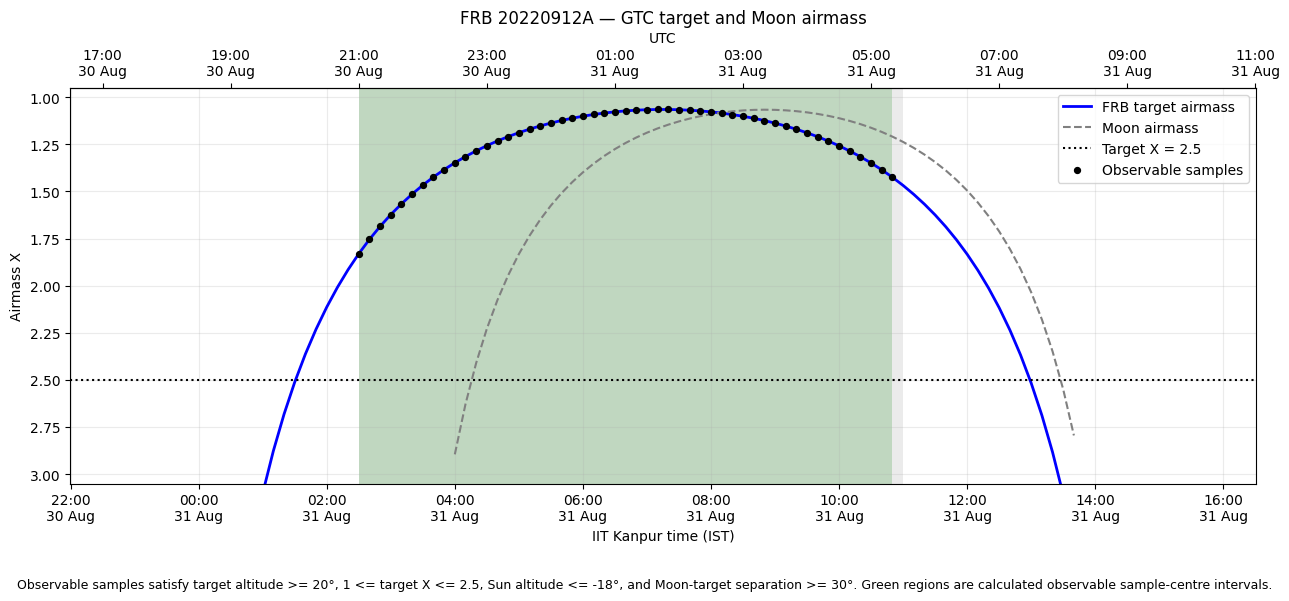

Saved: assignment_outputs/frb_20220912a_gtc_airmass.png
Scientific conclusion: the source is observable only where all four constraints overlap; high altitude alone is insufficient.
Limitation: the 10-minute grid can shift reported interval boundaries by several minutes and can miss a short interval between samples.


In [21]:
# Q18
def stitch_windows(times, visibility_state):
    times = list(times)
    state = np.asarray(visibility_state, dtype=bool)

    if state.ndim != 1 or len(state) != len(times):
        raise ValueError(
            "times and visibility_state must be one-dimensional and equal length."
        )

    windows = []
    i = 0

    while i < len(state):
        if not state[i]:
            i += 1
            continue

        start = i

        while i + 1 < len(state) and state[i + 1]:
            i += 1

        end = i
        windows.append((start, end))
        i += 1

    return windows


windows = stitch_windows(times, preferred_visibility)

print("Observable sample-centre intervals:")

if not windows:
    print("None")
else:
    for start_idx, end_idx in windows:
        midpoint_idx = (start_idx + end_idx) // 2

        duration = (
            times[end_idx] - times[start_idx]
        ).to_value(u.hour)

        local_airmass = target_airmass[start_idx:end_idx + 1]
        best_local_idx = start_idx + int(np.nanargmin(local_airmass))

        print(
            f"\nSamples {start_idx}..{end_idx}"
            f"\n  UTC: {format_utc(times[start_idx])} -> "
            f"{format_utc(times[end_idx])}"
            f"\n  IST: {format_iitk(times[start_idx])} -> "
            f"{format_iitk(times[end_idx])}"
            f"\n  Sample-centre duration: {duration:.3f} h"
            f"\n  Best target airmass: {target_airmass[best_local_idx]:.4f}"
            f" at {format_utc(times[best_local_idx])}"
            f"\n  Midpoint Moon label: {moon_labels[midpoint_idx]}"
        )


night = sun_altitude <= MAX_SUN_ALTITUDE_DEG
observable = preferred_visibility

fig, ax = plt.subplots(figsize=(13, 6))

x = times.to_datetime(timezone=IITK_TIMEZONE)

ax.plot(
    x,
    target_airmass,
    color="blue",
    linestyle="-",
    linewidth=2,
    label="FRB target airmass",
)

ax.plot(
    x,
    moon_airmass,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Moon airmass",
)

ax.axhline(
    MAX_AIRMASS,
    color="black",
    linestyle=":",
    label="Target X = 2.5",
)

ax.set_ylim(3.05, 0.95)
ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur time (IST)")

for i in range(len(times) - 1):
    if night[i]:
        ax.axvspan(
            x[i],
            x[i + 1],
            color="black",
            alpha=0.08,
            linewidth=0,
        )

for start_idx, end_idx in windows:
    ax.axvspan(
        x[start_idx],
        x[end_idx],
        color="green",
        alpha=0.18,
        linewidth=0,
    )

observable_indices = np.flatnonzero(observable)

ax.scatter(
    x[observable_indices],
    target_airmass[observable_indices],
    color="black",
    s=18,
    zorder=5,
    label="Observable samples",
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%H:%M\n%d %b",
        tz=IITK_TIMEZONE,
    )
)

ax.grid(True, alpha=0.25)

secax = ax.secondary_xaxis("top")
secax.xaxis.set_major_locator(
    mdates.HourLocator(interval=2, tz=timezone.utc)
)
secax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%H:%M\n%d %b",
        tz=timezone.utc,
    )
)
secax.set_xlabel("UTC")

ax.legend(loc="upper right")
ax.set_title("FRB 20220912A — GTC target and Moon airmass")

fig.text(
    0.5,
    0.01,
    "Observable samples satisfy target altitude >= 20°, "
    "1 <= target X <= 2.5, Sun altitude <= -18°, and "
    "Moon-target separation >= 30°. Green regions are calculated "
    "observable sample-centre intervals.",
    ha="center",
    fontsize=9,
)

fig.tight_layout(rect=[0, 0.06, 1, 1])

airmass_plot_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
fig.savefig(airmass_plot_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", airmass_plot_path)
print(
    "Scientific conclusion: the source is observable only where all four "
    "constraints overlap; high altitude alone is insufficient."
)
print(
    "Limitation: the 10-minute grid can shift reported interval boundaries "
    "by several minutes and can miss a short interval between samples."
)


### Explanation — Q18
`stitch_windows` groups consecutive True samples into inclusive sample-centre intervals. The figure visualizes target and Moon airmass, the X=2.5 threshold, astronomical night, calculated observable intervals, and the corresponding IST/UTC time axes. The principal limitation is the 10-minute temporal sampling, which limits boundary precision.


## Q19. Find the GTC visibility window of the repeating FRB on one date 

In [22]:
# Q19
q19_start = Time("2026-09-01T00:00:00", scale="utc")
q19_stop = Time("2026-09-02T00:00:00", scale="utc")
q19_step = 1 * u.min

q19_n = int(
    np.round(
        ((q19_stop - q19_start) / q19_step)
        .to_value(u.dimensionless_unscaled)
    )
)

q19_times = q19_start + np.arange(q19_n + 1) * q19_step

q19_altaz = frb_icrs.transform_to(
    AltAz(
        obstime=q19_times,
        location=gtc_location,
        pressure=0 * u.hPa,
    )
)

q19_alt = q19_altaz.alt.to_value(u.deg)
q19_X = np.asarray(q19_altaz.secz.value, dtype=float)

q19_X[
    (q19_alt <= 0)
    | ~np.isfinite(q19_X)
    | (q19_X < 1)
] = np.nan

with solar_system_ephemeris.set("builtin"):
    q19_sun_alt = get_sun(q19_times).transform_to(
        AltAz(
            obstime=q19_times,
            location=gtc_location,
            pressure=0 * u.hPa,
        )
    ).alt.to_value(u.deg)

q19_visible = (
    (q19_alt >= 0)
    & np.isfinite(q19_X)
    & (q19_X <= MAX_AIRMASS)
    & (q19_sun_alt <= MAX_SUN_ALTITUDE_DEG)
)

q19_windows = stitch_windows(q19_times, q19_visible)

print("Q19 visibility intervals for 2026-09-01:")

if not q19_windows:
    print("None")
else:
    total_hours = 0.0

    for s, e in q19_windows:
        duration = (
            q19_times[e] - q19_times[s]
        ).to_value(u.hour)

        total_hours += duration

        print(
            f"UTC: {format_utc(q19_times[s])} -> "
            f"{format_utc(q19_times[e])}"
            f"\nIST: {format_iitk(q19_times[s])} -> "
            f"{format_iitk(q19_times[e])}"
            f"\nDuration from sample centres: {duration:.3f} h\n"
        )

    print(
        "Total visible duration from sampled interval centres:",
        total_hours,
        "h",
    )

print(
    "Q19 uses the fixed FRB position and the GTC altitude/airmass/night "
    "conditions. The Moon is intentionally excluded."
)


Q19 visibility intervals for 2026-09-01:
UTC: 2026-09-01 00:00:00 UTC -> 2026-09-01 05:28:00 UTC
IST: 2026-09-01 05:30:00 IST -> 2026-09-01 10:58:00 IST
Duration from sample centres: 5.467 h

UTC: 2026-09-01 20:55:00 UTC -> 2026-09-02 00:00:00 UTC
IST: 2026-09-02 02:25:00 IST -> 2026-09-02 05:30:00 IST
Duration from sample centres: 3.083 h

Total visible duration from sampled interval centres: 8.549999999999999 h
Q19 uses the fixed FRB position and the GTC altitude/airmass/night conditions. The Moon is intentionally excluded.


### Explanation — Q19
Q19 treats FRB 20220912A as one fixed sky position and evaluates it throughout 2026-09-01. Unlike Q18, the Moon is excluded. A point is visible when it is above the horizon, satisfies X ≤ 2.5, and lies within astronomical night.


## Q20. Generate a one-year GTC visibility animation 

In [23]:
# Q20 — optional 2-mark bonus

import imageio.v2 as imageio

Q20_NSIDE = 16
Q20_NPIX = hp.nside2npix(Q20_NSIDE)

Q20_STEP_DAYS = 7
Q20_START = Time("2026-08-30T00:00:00", scale="utc")
Q20_STOP = Time("2027-08-29T00:00:00", scale="utc")

# 53 weekly dates: 0, 7, 14, ..., 364 days
q20_dates = Q20_START + np.arange(53) * (Q20_STEP_DAYS * u.day)

q20_frame_dir = OUTPUT_DIR / "q20_weekly_frames"
q20_frame_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Create HEALPix sky coordinates
# ------------------------------------------------------------

theta, pix_phi = hp.pix2ang(
    Q20_NSIDE,
    np.arange(Q20_NPIX),
    lonlat=False,
)

pixel_dec = (np.pi / 2 - theta) * u.rad
pixel_ra = pix_phi * u.rad

sky = SkyCoord(
    ra=pixel_ra,
    dec=pixel_dec,
    frame="icrs",
)

frame_paths = []

# ------------------------------------------------------------
# Generate one visibility map per week
# ------------------------------------------------------------

for frame_number, day in enumerate(q20_dates):

    print(
        f"Creating frame {frame_number + 1}/{len(q20_dates)}: "
        f"{day.utc.strftime('%Y-%m-%d')}"
    )

    # 24 hourly observation times
    day_times = day + np.arange(24) * u.hour

    # Arrays to store altitude and airmass
    altitude = np.empty((24, Q20_NPIX))
    airmass = np.empty((24, Q20_NPIX))

    # --------------------------------------------------------
    # Transform the sky separately for each hour
    # --------------------------------------------------------

    for hour_index, observation_time in enumerate(day_times):

        altaz_frame = AltAz(
            obstime=observation_time,
            location=gtc_location,
            pressure=0 * u.hPa,
        )

        sky_altaz = sky.transform_to(altaz_frame)

        altitude[hour_index, :] = sky_altaz.alt.to_value(u.deg)

        airmass[hour_index, :] = np.asarray(
            sky_altaz.secz.value,
            dtype=float,
        )

    # --------------------------------------------------------
    # Calculate Sun altitude for each hour
    # --------------------------------------------------------

    sun_altitude = np.empty(24)

    for hour_index, observation_time in enumerate(day_times):

        altaz_frame = AltAz(
            obstime=observation_time,
            location=gtc_location,
            pressure=0 * u.hPa,
        )

        with solar_system_ephemeris.set("builtin"):
            sun_altaz = get_sun(observation_time).transform_to(
                altaz_frame
            )

        sun_altitude[hour_index] = (
            sun_altaz.alt.to_value(u.deg)
        )

    # --------------------------------------------------------
    # Determine whether each sky pixel is visible
    # --------------------------------------------------------

    visible = (
        (altitude >= 0)
        & np.isfinite(airmass)
        & (airmass <= MAX_AIRMASS)
        & (
            sun_altitude[:, None]
            <= MAX_SUN_ALTITUDE_DEG
        )
    )

    # Count the number of visible hours for every HEALPix pixel
    visibility_hours = visible.sum(axis=0).astype(float)

    # --------------------------------------------------------
    # Create Mollweide visibility map
    # --------------------------------------------------------

    fig = plt.figure(figsize=(10, 5.5))

    hp.mollview(
        visibility_hours,
        fig=fig.number,
        title=(
            "GTC all-sky visibility — "
            f"{day.utc.strftime('%Y-%m-%d')}"
        ),
        unit="hours visible",
        min=0,
        max=24,
        cmap="viridis",
    )

    hp.graticule()

    # --------------------------------------------------------
    # Save frame
    # --------------------------------------------------------

    frame_path = (
        q20_frame_dir
        / f"gtc_visibility_{frame_number:03d}.png"
    )

    fig.savefig(
        frame_path,
        dpi=120,
        bbox_inches="tight",
    )

    plt.close(fig)

    frame_paths.append(frame_path)


# ------------------------------------------------------------
# Create GIF
# ------------------------------------------------------------

q20_gif_path = (
    OUTPUT_DIR
    / "gtc_all_sky_visibility_2026-08-30_to_2027-08-29.gif"
)

with imageio.get_writer(
    q20_gif_path,
    mode="I",
    duration=0.35,
    loop=0,
) as writer:

    for frame_path in frame_paths:
        writer.append_data(
            imageio.imread(frame_path)
        )


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print()
print("Number of weekly frames:", len(frame_paths))
print("First date:", q20_dates[0].utc.isot)
print("Final date:", q20_dates[-1].utc.isot)
print("Saved GIF:", q20_gif_path)
print("Saved frames:", q20_frame_dir)

print(
    "The visible sky changes through the year because Earth's "
    "orbital motion changes the Sun's apparent position against "
    "the celestial sphere. The GTC latitude and airmass limit "
    "additionally control which declinations can be observed "
    "at acceptable altitude."
)

Creating frame 1/53: 2026-08-30


/home/soumi/Desktop/base/lib/python3.12/site-packages/healpy/visufunc.py:225: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Creating frame 2/53: 2026-09-06
Creating frame 3/53: 2026-09-13
Creating frame 4/53: 2026-09-20
Creating frame 5/53: 2026-09-27
Creating frame 6/53: 2026-10-04
Creating frame 7/53: 2026-10-11
Creating frame 8/53: 2026-10-18
Creating frame 9/53: 2026-10-25
Creating frame 10/53: 2026-11-01
Creating frame 11/53: 2026-11-08
Creating frame 12/53: 2026-11-15
Creating frame 13/53: 2026-11-22
Creating frame 14/53: 2026-11-29
Creating frame 15/53: 2026-12-06
Creating frame 16/53: 2026-12-13
Creating frame 17/53: 2026-12-20
Creating frame 18/53: 2026-12-27
Creating frame 19/53: 2027-01-03
Creating frame 20/53: 2027-01-10
Creating frame 21/53: 2027-01-17
Creating frame 22/53: 2027-01-24
Creating frame 23/53: 2027-01-31
Creating frame 24/53: 2027-02-07
Creating frame 25/53: 2027-02-14
Creating frame 26/53: 2027-02-21
Creating frame 27/53: 2027-02-28
Creating frame 28/53: 2027-03-07
Creating frame 29/53: 2027-03-14
Creating frame 30/53: 2027-03-21


Creating frame 31/53: 2027-03-28
Creating frame 32/53: 2027-04-04
Creating frame 33/53: 2027-04-11
Creating frame 34/53: 2027-04-18
Creating frame 35/53: 2027-04-25
Creating frame 36/53: 2027-05-02
Creating frame 37/53: 2027-05-09
Creating frame 38/53: 2027-05-16
Creating frame 39/53: 2027-05-23
Creating frame 40/53: 2027-05-30
Creating frame 41/53: 2027-06-06
Creating frame 42/53: 2027-06-13
Creating frame 43/53: 2027-06-20
Creating frame 44/53: 2027-06-27
Creating frame 45/53: 2027-07-04
Creating frame 46/53: 2027-07-11
Creating frame 47/53: 2027-07-18
Creating frame 48/53: 2027-07-25
Creating frame 49/53: 2027-08-01
Creating frame 50/53: 2027-08-08
Creating frame 51/53: 2027-08-15
Creating frame 52/53: 2027-08-22
Creating frame 53/53: 2027-08-29

Number of weekly frames: 53
First date: 2026-08-30T00:00:00.000
Final date: 2027-08-29T00:00:00.000
Saved GIF: assignment_outputs/gtc_all_sky_visibility_2026-08-30_to_2027-08-29.gif
Saved frames: assignment_outputs/q20_weekly_frames
The vis

### Explanation — Q20
The bonus uses HEALPix to represent the full celestial sphere with equal-area pixels. For each weekly date it estimates the number of hours each sky pixel satisfies the GTC altitude, airmass, and astronomical-night conditions, saves a PNG, and combines the weekly frames into a GIF. The observable region changes over the year because Earth's orbit changes the Sun's apparent position on the celestial sphere.


# Declaration AI useage

AI assistance has been used to understand the packages and design optimal algorithms to write the codes effectively better.
